In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from functools import reduce # for reducing a list of matrices to a single matrix
from itertools import product
import h5py # for storing data

### AKLT model


<font face="serif" color=lightblue> In this notebook, we look at the properties of the 1D AKLT model with spin 1. The model hamiltonian is:
$$H=\sum_{i=1}^L \frac{1}{3} + \frac{1}{2} S_x\cdot S_{x+1} + \frac{1}{6} (S_x\cdot S_{x+1})^2 = \sum_{x=1}^L P_2[S_x + S_{x+1}]$$

We will compute the
- energy spectrum w/ GS degeneracies
- string order parameter
- two-point correlation function

In [22]:
def AKLT_hamiltonian(L, periodic=True):
    """
    Constructs the AKLT Hamiltonian for a spin-1 chain of length L.

    Parameters:
    L : int
        Length of the spin chain.
    periodic: bool, optional
        Boundary condition of the chain.
    """

    dim = 3**L # Total Hilbert space dimension

    # 1. Define local spin Operators
    sz = sp.csr_matrix([[1, 0, 0], [0, 0, 0], [0, 0, -1]]) # S^z
    s_plus = np.sqrt(2) * sp.csr_matrix([[0, 1, 0], [0, 0, 1], [0, 0, 0]]) # S^+
    s_minus = np.sqrt(2) * sp.csr_matrix([[0, 0, 0], [1, 0, 0], [0, 1, 0]]) # S^-
    id = sp.eye(3, format='csr') # Identity
    Id = sp.eye(dim, format='csr') # Global Identity

    # 2. Construct the Hamiltonian
    H = sp.csr_matrix((dim, dim), dtype=np.float64) # Initialize Hamiltonian

    for i in range(L-1): # OBC
        # Construct global spin operator for sites i and j
        
        H_c = reduce(sp.kron, [id]*i + [sz]*2 + [id]*(L-i-2))
        H_q1 = 0.5 * reduce(sp.kron, [id]*i + [s_plus, s_minus] + [id]*(L-i-2)) # Quantum part 1
        H_q2 = 0.5 * reduce(sp.kron, [id]*i + [s_minus, s_plus] + [id]*(L-i-2)) # Quantum part 2
        H += (1/3)*Id + (1/2)*(H_c + H_q1 + H_q2) + (1/6)*(H_c + H_q1 + H_q2) @ (H_c + H_q1 + H_q2) # AKLT Hamiltonian term

    if periodic:
        # Periodic boundary conditions
        H_c = reduce(sp.kron, [sz] + [id]*(L-2) + [sz])
        H_q1 = 0.5 * reduce(sp.kron, [s_plus] + [id]*(L-2) + [s_minus])
        H_q2 = 0.5 * reduce(sp.kron, [s_minus] + [id]*(L-2) + [s_plus])
        H += (1/3)*Id + (1/2)*(H_c + H_q1 + H_q2) + (1/6)*(H_c + H_q1 + H_q2) @ (H_c + H_q1 + H_q2) # AKLT Hamiltonian term

    return H

In [23]:
def save_AKLT_data(filename, L, periodic, energies, states):
    """
    Saves eigenvalues and eigenvectors into a structured HDF5 file.
    """
    with h5py.File(filename, "a") as f:
        # Create a unique heirarchical path for this parameter set
        group_path = f"L_{L}/periodic_{periodic}"
        if group_path in f:
            del f[group_path]  # Overwrite cleanly if it already exists

        group = f.create_group(group_path)

        # Save the numerical arrays
        group.create_dataset("energies", data=energies, compression="gzip", compression_opts=4)
        group.create_dataset("states", data=states, compression="gzip", compression_opts=4)

        # Save metadata directly attached to this run
        group.attrs["L"] = L
        group.attrs["periodic"] = periodic
        group.attrs["description"] = "AKLT model ED"

def print_hdf5_metadata(name, obj):
    """Callback function to inspect each item in the HDF5 file."""
    # Indent based on hierarchy depth for readability
    depth = name.count('/')
    indent = "  " * depth
    
    if isinstance(obj, h5py.Group):
        print(f"{indent}📁 Group: {name}")
    elif isinstance(obj, h5py.Dataset):
        print(f"{indent}📄 Dataset: {name} (shape={obj.shape}, dtype={obj.dtype})")
    
    # Check and print any metadata attributes attached to this object
    if len(obj.attrs) > 0:
        for key, val in obj.attrs.items():
            print(f"{indent}    ⚙️ Attribute -> {key}: {val}")

# Here is how you read the data
"""
filename = "ED_AKLT_data.h5"
with h5py.File(filename, "r") as f:
    # Access data directly like a dictionary
    read_energies = f["L_12/g_0.0/energies"][:]
    read_states = f["L_12/g_0.0/states"][:]
"""

# Here is how you read all the metadata and attributes
"""
# Open and inspect the file
filename = "ED_AKLT_data.h5"
with h5py.File(filename, "r") as f:
    print(f"--- Metadata Structure for {filename} ---")
    # Print root-level attributes if any exist
    for key, val in f.attrs.items():
        print(f"Root Attribute -> {key}: {val}")
        
    # Recursively visit all paths
    f.visititems(print_hdf5_metadata)
"""

'\n# Open and inspect the file\nfilename = "ED_AKLT_data.h5"\nwith h5py.File(filename, "r") as f:\n    print(f"--- Metadata Structure for {filename} ---")\n    # Print root-level attributes if any exist\n    for key, val in f.attrs.items():\n        print(f"Root Attribute -> {key}: {val}")\n\n    # Recursively visit all paths\n    f.visititems(print_hdf5_metadata)\n'

### Compute & save data here

In [24]:
L = 12
periodic = True
num_levels = 10

"""Uncomment when you want to generate and save new data. This will overwrite existing data for the same L and g values."""
H = AKLT_hamiltonian(L=L, periodic=periodic)
energies, states = spla.eigsh(H, k=num_levels, which='SA')

# Sort the energies and states
sort_indices = np.argsort(energies)
energies = energies[sort_indices]
states = states[:, sort_indices]

filename = "ED_AKLT_data.h5"
save_AKLT_data(filename=filename, L=L, periodic=periodic, energies=energies, states=states)
print(f"Saved data for L={L}, periodic={periodic} to {filename}")

Saved data for L=12, periodic=True to ED_AKLT_data.h5


### Energy spectrum w/ GS degeneracies


 SPECTRUM & DEGENERACY: L=4, periodic=True
Level Index    Energy (E)        Degeneracy
----------------------------------------------------
0              -2.666667         1         
1              -2.000000         3         
2              -1.194192         6         

Haldane gap: 0.666667
Exact gap for AKLT: 0.350085(2)


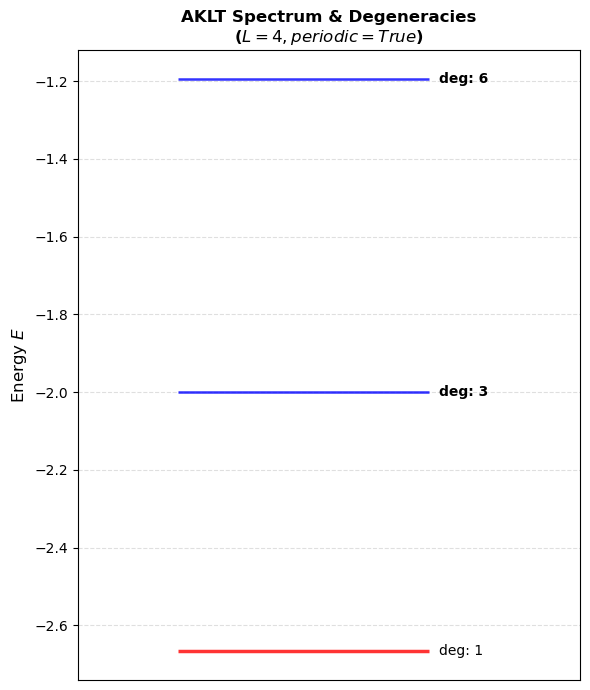

In [19]:
def plot_AKLT_spectrum(filename, L, periodic, atol=1e-5):
    """
    Loads eigenvalues from HDF5, calculates the degeneracy of each energy level,
    prints a summary, and plots the spectrum with degeneracy counts.
    """
    group_path = f"L_{L}/periodic_{periodic}"
    
    with h5py.File(filename, "r") as f:
        if group_path not in f:
            print(f"Error: Data path '{group_path}' not found in {filename}")
            return
        energies = f[group_path]["energies"][:]
    # --- Calculate Degeneracies ---
    # Group energies that are within 'atol' of each other
    unique_energies = []
    degeneracies = []
    
    for E in energies:
        if not unique_energies:
            unique_energies.append(E)
            degeneracies.append(1)
        else:
            # Check if this energy matches an already identified unique level
            if np.isclose(E, unique_energies[-1], atol=atol):
                degeneracies[-1] += 1
            else:
                unique_energies.append(E)
                degeneracies.append(1)
                
    # --- Print Summary Table ---
    print(f"\n====================================================")
    print(f" SPECTRUM & DEGENERACY: L={L}, periodic={periodic}")
    print(f"====================================================")
    print(f"{'Level Index':<15}{'Energy (E)':<18}{'Degeneracy':<10}")
    print(f"----------------------------------------------------")
    for idx, (E, deg) in enumerate(zip(unique_energies, degeneracies)):
        print(f"{idx:<15}{E:<18.6f}{deg:<10d}")
    print(f"====================================================\n")
    print(f"Haldane gap: {unique_energies[1] - unique_energies[0]:.6f}")
    print(f"Exact gap for AKLT: 0.350085(2)")


    # --- Plotting ---
    plt.figure(figsize=(6, 7))
    
    # Plot unique levels and label their degeneracies
    for E, deg in zip(unique_energies, degeneracies):
        # Ground state in red, excited states in blue
        color = 'red' if E == unique_energies[0] else 'blue'
        lw = 2.5 if E == unique_energies[0] else 1.8
        
        plt.hlines(E, xmin=0.2, xmax=0.7, colors=color, linewidth=lw, alpha=0.8)
        
        # Add text label for degeneracy to the right of each line
        plt.text(0.72, E, f"deg: {deg}", verticalalignment='center', fontsize=10, 
                 fontweight='bold' if deg > 1 else 'normal')

    plt.ylabel("Energy $E$", fontsize=12)
    plt.xlim(0, 1.0)
    plt.xticks([])  # Strip X ticks since it's a 1D vertical energy alignment
    plt.title(f"AKLT Spectrum & Degeneracies\n($L={L}, periodic={periodic}$)", fontsize=12, fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

plot_AKLT_spectrum("ED_AKLT_data.h5", L=4, periodic=True, atol=1e-5)

### String order parameter

<font face="serif" color=lightblue> The GS of the AKLT model is a superposition of all states with hidden antiferromagnetic order, which can be measured by the string order parameter:
$$ \mathcal{S}_{x, y} = - \langle \Phi_{\text{GS}} | S_x^{(3)} \exp\left(i\pi\sum_{x<i<y} S_i^{(3)}\right) S_y^{(3)} | \Phi_{\text{GS}} \rangle $$

The string of spin operators between first and last site counts the number of flips between + and - states, ignoring zero states. 

In [10]:
def string_order_parameter(filename, L, periodic, first_site, last_site, one_indexed=False):
    """
    Compute the z-string order parameter for the AKLT GS.

    Parameters
    ----------
    state : array-like
        Ground-state vector in the S^z product basis.
    first_site : int
        Starting site of the string operator.
    last_site : int
        Ending site of the string operator.

    Returns
    -------
    float
        The string order parameter
        -<S^z_first exp(i*pi*sum S^z) S^z_last>.
    """

    group_path = f"L_{L}/periodic_{periodic}"

    with h5py.File(filename, "r") as f:
        if group_path not in f:
            print(f"Error: Data path '{group_path}' not found in {filename}")
            return
        state = f[group_path]["states"][:, 0]

    if not (0 <= first_site < last_site < L):
        raise ValueError(f"Require 0 <= first_site < last_site < {L}.")

    # Map the product-basis digits to S^z eigenvalues: 0 -> +1, 1 -> 0, 2 -> -1.
    dim = 3**L
    basis_digits = np.empty((L, dim), dtype=np.int8)
    indices = np.arange(dim, dtype=np.int64)
    for site in range(L - 1, -1, -1):
        indices, basis_digits[site] = divmod(indices, 3)

    sz_values = 1 - basis_digits
    endpoint_factor = sz_values[first_site] * sz_values[last_site]

    if last_site - first_site > 1:
        middle_sites = sz_values[first_site + 1:last_site]
        string_factor = np.prod(np.where(middle_sites == 0, 1, -1), axis=0)
    else:
        string_factor = 1

    # Compute order parameters
    probabilities = np.abs(state) ** 2
    string_order = float(-np.sum(probabilities * endpoint_factor * string_factor))

    # Display results
    print(f"String order parameter (L={L}, sites {first_site} to {last_site}): {string_order:.8f}")
    print(f"The exact value in thermodynamic limit is 4/9 ≈ 0.44444444")

    return string_order

# Example
string_order = string_order_parameter(filename="ED_AKLT_data.h5", L=12, periodic=False, first_site=0, last_site=11)

String order parameter (L=12, sites 0 to 11): 0.44444345
The exact value in thermodynamic limit is 4/9 ≈ 0.44444444


### Two-point correlation function

In [98]:
def two_point_correlation(filename, L, periodic):
    """
    Compute the two-point correlation function for the AKLT GS.

    Parameters
    ----------
    state : array-like
        Ground-state vector in the S^z product basis. If a 2D array is passed,
        the first column is used.

    Returns
    -------
    float
        The string order parameter
        -<S^z_first exp(i*pi*sum S^z) S^z_last>.
    """

    group_path = f"L_{L}/periodic_{periodic}"

    with h5py.File(filename, "r") as f:
        if group_path not in f:
            print(f"Error: Data path '{group_path}' not found in {filename}")
            return
        state = f[group_path]["states"][:, 0]

    # Map the product-basis digits to S^z eigenvalues: 0 -> +1, 1 -> 0, 2 -> -1.
    dim = 3**L
    basis_digits = np.empty((L, dim), dtype=np.int8)
    indices = np.arange(dim, dtype=np.int64)
    for site in range(L - 1, -1, -1):
        indices, basis_digits[site] = divmod(indices, 3)

    # Compute two-point correlation function
    print(f"\n--- Correlation Function C(r) ---")
    print(f"{'Distance r':<12}{'C(r) = <S_0 . S_r>':<22}")
    print("-" * 35)
    sz_values = 1 - basis_digits
    correlations = []
    for site in range(1, L):
        correlation = np.sum(np.abs(state) ** 2 * sz_values[0] * sz_values[site])
        correlations.append(correlation)
        print(f"{site:<12}{correlation:<22.6f}")

    return correlations

# Example
correlations = two_point_correlation(filename="ED_AKLT_data.h5", L=12, periodic=False)



--- Correlation Function C(r) ---
Distance r  C(r) = <S_0 . S_r>    
-----------------------------------
1           -0.444443             
2           0.148145              
3           -0.049373             
4           0.016433              
5           -0.005403             
6           0.001578              
7           0.000145              
8           -0.002060             
9           0.006721              
10          -0.020345             
11          0.061094              


<font face="serif" color=lightblue> Observe that for C(1) is exactly the string order parameter (by a minus sign). This is merely a special case of string order with only endpoints. One can also see the lack of clear antiferromagnetic correlation in the GS of AKLT model.

### Effective edge spin-1/2

<font face="serif" color=lightblue> Using the MPS representation of AKLT ground state, one can approximate analytically the expectation value of spin-z component across the chain:
$$ \langle S_x^{(3)} \rangle \approx \frac{2}{3} \left[ \left( -\frac{1}{3} \right)^{x-1} + \left( -\frac{1}{3} \right)^{L-x} \right] $$
Numerically, exact diagonalization of the full hamiltonian matrix gives superpositions of four degenerate ground states. To isolate the state $| \Phi_{\text{VBS}}^{\uparrow \uparrow} \rangle$, we can obtain the symmetry block of $S_{\text{tot}}^{(3)} = 1$ of the full matrix and diagonalize the block for the corresponding ground state $| \Phi_{\text{VBS}}^{\uparrow \uparrow} \rangle$. Then we measure the spin-z component across the chain as usual.

Ground state energy in S_z=1 sector: 0.00000000

Site-by-site <S_x^z> profile:
Site  1:  0.666667
Site  2: -0.222222
Site  3:  0.074074
Site  4: -0.024690
Site  5:  0.008227
Site  6: -0.002732
Site  7:  0.000881
Site  8: -0.000203
Site  9: -0.000203
Site 10:  0.000881
Site 11: -0.002732
Site 12:  0.008227
Site 13: -0.024690
Site 14:  0.074074
Site 15: -0.222222
Site 16:  0.666667


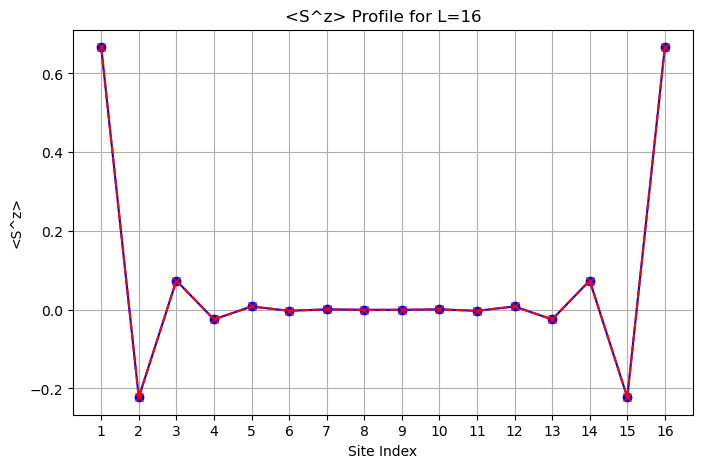

In [ ]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from functools import reduce

def AKLT_hamiltonian(L, periodic=False):
    dim = 3**L
    sz = sp.csr_matrix([[1, 0, 0], [0, 0, 0], [0, 0, -1]])
    s_plus = np.sqrt(2) * sp.csr_matrix([[0, 1, 0], [0, 0, 1], [0, 0, 0]])
    s_minus = np.sqrt(2) * sp.csr_matrix([[0, 0, 0], [1, 0, 0], [0, 1, 0]])
    id_site = sp.eye(3, format='csr')
    Id = sp.eye(dim, format='csr')

    H = sp.csr_matrix((dim, dim), dtype=np.float64)

    for i in range(L - 1):
        H_c = reduce(sp.kron, [id_site]*i + [sz]*2 + [id_site]*(L - i - 2))
        H_q1 = 0.5 * reduce(sp.kron, [id_site]*i + [s_plus, s_minus] + [id_site]*(L - i - 2))
        H_q2 = 0.5 * reduce(sp.kron, [id_site]*i + [s_minus, s_plus] + [id_site]*(L - i - 2))
        S_dot_S = H_c + H_q1 + H_q2
        H += (1/3)*Id + (1/2)*S_dot_S + (1/6)*(S_dot_S @ S_dot_S)

    if periodic:
        H_c = reduce(sp.kron, [sz] + [id_site]*(L - 2) + [sz])
        H_q1 = 0.5 * reduce(sp.kron, [s_plus] + [id_site]*(L - 2) + [s_minus])
        H_q2 = 0.5 * reduce(sp.kron, [s_minus] + [id_site]*(L - 2) + [s_plus])
        S_dot_S = H_c + H_q1 + H_q2
        H += (1/3)*Id + (1/2)*S_dot_S + (1/6)*(S_dot_S @ S_dot_S)

    return H

def get_sz_sector_indices(L, target_sz):
    """
    Returns the indices of basis states in the full Hilbert space (3^L)
    that have a total S_z equal to target_sz.
    """
    all_k = np.arange(3**L)
    powers = 3 ** np.arange(L - 1, -1, -1)
    
    # Convert integer k to base-3 digits (shape: [3**L, L])
    digits = (all_k[:, None] // powers[None, :]) % 3
    
    # Map digits to Sz values: 0 -> +1, 1 -> 0, 2 -> -1
    sz_matrix = 1 - digits
    
    # Calculate total Sz for each basis state
    total_sz = sz_matrix.sum(axis=1)
    
    # Find indices where total Sz matches the target
    sector_indices = np.where(total_sz == target_sz)[0]
    return sector_indices

def measure_edge_spins(L, target_sz=1):
    # 1. Build full Hamiltonian & slice
    H_full = AKLT_hamiltonian(L, periodic=False)
    indices = get_sz_sector_indices(L, target_sz)
    H_sub = H_full[indices][:, indices]
    
    # 2. Diagonalize for ground state
    energies, vecs = spla.eigsh(H_sub, k=1, which='SA')
    psi_0 = vecs[:, 0]
    
    print(f"Ground state energy in S_z={target_sz} sector: {energies[0]:.8f}")
    
    # 3. Extract site spin values directly from basis digits (Fast & Exact)
    powers = 3 ** np.arange(L - 1, -1, -1)
    digits = (indices[:, None] // powers[None, :]) % 3
    sz_matrix = 1 - digits  # Shape: (dim_sub, L), contains local Sz values (+1, 0, -1)
    
    # 4. Compute expectation values: sum_k |psi_0[k]|^2 * sz_matrix[k, x]
    probabilities = np.abs(psi_0)**2
    exp_sz = probabilities @ sz_matrix
    
    return exp_sz

def plot_sz_profile(sz_profile):

    site_index = np.arange(1, len(sz_profile) + 1)
    exact_sz = (2/3) * (-1/3)**(site_index - 1) + (2/3) * (-1/3)**(len(sz_profile) - site_index)

    plt.figure(figsize=(8, 5))
    plt.plot(site_index, sz_profile, marker='o', linestyle='-', color='b')
    plt.plot(site_index, exact_sz, marker='x', linestyle='--', color='r')
    plt.title(f"<S^z> Profile for L={len(sz_profile)}")
    plt.xlabel("Site Index")
    plt.ylabel("<S^z>")
    plt.xticks(range(1, len(sz_profile) + 1))
    plt.grid()
    plt.show()

# Example usage for L = 8
L = 16
sz_profile = measure_edge_spins(L, target_sz=1)

print("\nSite-by-site <S_x^z> profile:")
for x, val in enumerate(sz_profile, 1):
    print(f"Site {x:2d}: {val: .6f}")
plot_sz_profile(sz_profile)

<font face="serif" color=lightblue> It took 22 minutes to get the plot for L=16. Recall under periodic boundary condition, we can construct the matrix product state of AKLT model:
$$ |\Phi_{\text{GS, PBC}}\rangle = \sum_{\sigma_1, ..., \sigma_L} \text{Tr}(A^{\sigma_1} ... A^{\sigma_L}) |\sigma_1 ... \sigma_L\rangle $$

Similarly under open boundary condition, we have:
$$ |\Phi_{\text{GS, OBC}}^{v_L, v_R}\rangle = \sum_{\sigma_1, ..., \sigma_L} \text{Tr}(v_L^T A^{\sigma_1} ... A^{\sigma_L} v_R) |\sigma_1 ... \sigma_L\rangle $$

where $v_L, v_R \in \{ (1, 0)^T, (0, 1)^T \}$, corresponding to virtual states $|\uparrow\rangle, |\downarrow\rangle$ respectively. This provides a benchmark for the measurement of exponentially localized edge spin.

In [ ]:
import numpy as np
import itertools

def get_aklt_mps_ground_states(L):
    """
    Constructs the 4 degenerate ground state vectors of an open AKLT chain of length L
    using the Matrix Product State (MPS) representation.
    
    Returns:
        dict: A dictionary containing normalized state vectors (size 3^L)
              for each edge spin configuration: 'up_up', 'up_down', 'down_up', 'down_down'.
    """
    # 1. Define AKLT MPS Matrices (D = 2)
    # Basis order: index 0 -> |+1>, index 1 -> |0>, index 2 -> |-1>
    A = {
        0: np.array([[0.0, np.sqrt(2)], 
                     [0.0, 0.0]]),        # A^+ = sqrt(2) * sigma^+
        
        1: np.array([[-1.0, 0.0], 
                     [0.0, 1.0]]),        # A^0 = -sigma_z
        
        2: np.array([[0.0, 0.0], 
                     [-np.sqrt(2), 0.0]]) # A^- = -sqrt(2) * sigma^-
    }

    # 2. Define Boundary Vectors v_L and v_R in C^2
    spin_up = np.array([1.0, 0.0])
    spin_down = np.array([0.0, 1.0])

    boundary_configs = {
        'up_up':     (spin_up, spin_up),     # S_tot^z = +1
        'up_down':   (spin_up, spin_down),   # S_tot^z =  0
        'down_up':   (spin_down, spin_up),   # S_tot^z =  0
        'down_down': (spin_down, spin_down)  # S_tot^z = -1
    }

    dim = 3**L
    ground_states = {}

    # 3. Construct each state vector in full 3^L Hilbert space
    for config_name, (v_L, v_R) in boundary_configs.items():
        psi = np.zeros(dim, dtype=np.float64)
        
        # Iterate over all 3^L computational basis configurations
        for digits in itertools.product([0, 1, 2], repeat=L):
            # Compute global index in base-3
            index = sum(d * (3**(L - 1 - i)) for i, d in enumerate(digits))
            
            # Compute matrix product v_L^T @ A^{s1} @ A^{s2} ... @ A^{sL} @ v_R
            mat_prod = A[digits[0]]
            for d in digits[1:]:
                mat_prod = mat_prod @ A[d]
                
            coeff = v_L.T @ mat_prod @ v_R
            psi[index] = coeff

        # Normalize state
        psi /= np.linalg.norm(psi)
        ground_states[config_name] = psi

    return ground_states


# ==========================================
# Verification & Example Usage
# ==========================================
if __name__ == "__main__":
    L = 10
    states = get_aklt_mps_ground_states(L)
    
    print(f"Constructed 4 MPS ground states for L = {L}:")
    for name, vec in states.items():
        print(f"State '{name:10s}': Vector norm = {np.linalg.norm(vec):.4f}, Dimension = {len(vec)}")

    # Verify orthogonality between the |up_up> and |down_down> states
    overlap = np.vdot(states['up_up'], states['down_down'])
    print(f"\nOverlap <up_up | down_down>: {overlap:.8f}")

Constructed 4 MPS ground states for L = 10:
State 'up_up     ': Vector norm = 1.0000, Dimension = 59049
State 'up_down   ': Vector norm = 1.0000, Dimension = 59049
State 'down_up   ': Vector norm = 1.0000, Dimension = 59049
State 'down_down ': Vector norm = 1.0000, Dimension = 59049

Overlap <up_up | down_down>: 0.00003387


In [9]:
# ==========================================
# 2. Local Spin Measurement Function
# ==========================================
def measure_local_spin(psi, L, op_3x3):
    """
    Measures the expectation value of a single-site 3x3 operator at every site x = 1...L
    using tensor reshaping (no large matrices required).
    
    Parameters:
        psi (ndarray): State vector of dimension 3^L.
        L (int): Chain length.
        op_3x3 (ndarray): Local 3x3 operator matrix (e.g., S_z, S_x, S_y).
        
    Returns:
        ndarray: Array of length L containing <op_x> for x = 1 ... L.
    """
    # Reshape 1D vector into an L-index tensor: (3, 3, ..., 3)
    psi_tensor = psi.reshape([3] * L)
    profile = []

    for site in range(L):
        # Permute the target site index to axis 0
        psi_permuted = np.moveaxis(psi_tensor, site, 0)
        
        # Flatten remaining axes into shape (3, 3^(L-1))
        psi_matrix = psi_permuted.reshape(3, -1)
        
        # Apply local operator to axis 0: (op @ psi_matrix)
        op_psi = op_3x3 @ psi_matrix
        
        # Compute expectation value <psi| op_x |psi>
        val = np.sum(np.conj(psi_matrix) * op_psi).real
        profile.append(val)

    return np.array(profile)


# ==========================================
# 3. Main Script: Spin Measurements
# ==========================================
if __name__ == "__main__":

    # Define Spin-1 Local Operators
    sz = np.array([[1.0, 0.0, 0.0],
                   [0.0, 0.0, 0.0],
                   [0.0, 0.0, -1.0]])

    sx = (1.0 / np.sqrt(2)) * np.array([[0.0, 1.0, 0.0],
                                        [1.0, 0.0, 1.0],
                                        [0.0, 1.0, 0.0]])

    sy = (1.0j / np.sqrt(2)) * np.array([[0.0, -1.0, 0.0],
                                         [1.0, 0.0, -1.0],
                                         [0.0, 1.0, 0.0]])

    print(f"==================================================")
    print(f" <S_x^z> Profiles for Open AKLT Chain (L = {L})")
    print(f"==================================================")
    
    header = f"{'Site':^6} | {'up_up':^10} | {'up_down':^10} | {'down_up':^10} | {'down_down':^10}"
    print(header)
    print("-" * len(header))

    # Compute <S_x^z> profiles for all 4 states
    profiles_sz = {name: measure_local_spin(vec, L, sz) for name, vec in states.items()}

    for site in range(L):
        val_uu = profiles_sz['up_up'][site]
        val_ud = profiles_sz['up_down'][site]
        val_du = profiles_sz['down_up'][site]
        val_dd = profiles_sz['down_down'][site]
        print(f"{site + 1:^6d} | {val_uu: ^10.6f} | {val_ud: ^10.6f} | {val_du: ^10.6f} | {val_dd: ^10.6f}")

    print("\n" + "=" * 50)
    print(" Transverse Spin Measurements Check (<S_x^x> and <S_x^y>)")
    print("=" * 50)
    
    # Check transverse components for the 'up_up' state
    sx_profile = measure_local_spin(states['up_up'], L, sx)
    sy_profile = measure_local_spin(states['up_up'], L, sy)
    
    print(f"Max |<S_x^x>| across chain: {np.max(np.abs(sx_profile)):.12f}")
    print(f"Max |<S_x^y>| across chain: {np.max(np.abs(sy_profile)):.12f}")

 <S_x^z> Profiles for Open AKLT Chain (L = 10)
 Site  |   up_up    |  up_down   |  down_up   | down_down 
----------------------------------------------------------
  1    |  0.666689  |  0.666644  | -0.666644  | -0.666689 
  2    | -0.222320  | -0.222124  |  0.222124  |  0.222320 
  3    |  0.074378  |  0.073770  | -0.073770  | -0.074378 
  4    | -0.025605  | -0.023777  |  0.023777  |  0.025605 
  5    |  0.010974  |  0.005487  | -0.005487  | -0.010974 
  6    | -0.010974  |  0.005487  | -0.005487  |  0.010974 
  7    |  0.025605  | -0.023777  |  0.023777  | -0.025605 
  8    | -0.074378  |  0.073770  | -0.073770  |  0.074378 
  9    |  0.222320  | -0.222124  |  0.222124  | -0.222320 
  10   | -0.666689  |  0.666644  | -0.666644  |  0.666689 

 Transverse Spin Measurements Check (<S_x^x> and <S_x^y>)
Max |<S_x^x>| across chain: 0.000000000000
Max |<S_x^y>| across chain: 0.000000000000


## Topological Phase Transition in Anisotropic Model

<font face="serif" color=lightblue> In this section, we discuss the Haldane phase by investigating the low energy properties of the anisotropic S=1 antiferromagnetic Hamiltonian under PBC and even L:
$$ H(D) = \sum_{x=1}^L \left\{ S_x S_{x+1} + D(S_x^{(3)})^2 \right\} $$

where $D \geq 0$ is a parameter we tune to look for phase transition.

In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from functools import reduce # for reducing a list of matrices to a single matrix
from itertools import product
import h5py # for storing data

In [2]:
def aniso_AKLT_hamiltonian(L, D=0, periodic=True):
    """
    Constructs the anisotropic AKLT Hamiltonian for a spin-1 chain of length L.

    Parameters:
    L : int
        Length of the spin chain.
    D : float, optional
        Anisotropy parameter.
    periodic: bool, optional
        Boundary condition of the chain.
    """

    dim = 3**L # Total Hilbert space dimension

    # 1. Define local spin Operators
    sz = sp.csr_matrix([[1, 0, 0], [0, 0, 0], [0, 0, -1]]) # S^z
    s_plus = np.sqrt(2) * sp.csr_matrix([[0, 1, 0], [0, 0, 1], [0, 0, 0]]) # S^+
    s_minus = np.sqrt(2) * sp.csr_matrix([[0, 0, 0], [1, 0, 0], [0, 1, 0]]) # S^-
    id = sp.eye(3, format='csr') # Identity
    Id = sp.eye(dim, format='csr') # Global Identity

    # 2. Construct the Hamiltonian
    H = sp.csr_matrix((dim, dim), dtype=np.float64) # Initialize Hamiltonian

    for i in range(L-1): # OBC
        # Construct global spin operator for sites i and j
        
        H_c = reduce(sp.kron, [id]*i + [sz]*2 + [id]*(L-i-2))
        H_q1 = 0.5 * reduce(sp.kron, [id]*i + [s_plus, s_minus] + [id]*(L-i-2)) # Quantum part 1
        H_q2 = 0.5 * reduce(sp.kron, [id]*i + [s_minus, s_plus] + [id]*(L-i-2)) # Quantum part 2
        H += (1/3)*Id + (1/2)*(H_c + H_q1 + H_q2) + (1/6)*(H_c + H_q1 + H_q2) @ (H_c + H_q1 + H_q2) + D * H_c @ H_c
    if periodic:
        # Periodic boundary conditions
        H_c = reduce(sp.kron, [sz] + [id]*(L-2) + [sz])
        H_q1 = 0.5 * reduce(sp.kron, [s_plus] + [id]*(L-2) + [s_minus])
        H_q2 = 0.5 * reduce(sp.kron, [s_minus] + [id]*(L-2) + [s_plus])
        H += (1/3)*Id + (1/2)*(H_c + H_q1 + H_q2) + (1/6)*(H_c + H_q1 + H_q2) @ (H_c + H_q1 + H_q2) + D * H_c @ H_c
        
    return H

In [6]:
def save_aniso_AKLT_data(filename, L, D, periodic, energies, states):
    """
    Saves eigenvalues and eigenvectors into a structured HDF5 file.
    """
    with h5py.File(filename, "a") as f:
        # Create a unique heirarchical path for this parameter set
        group_path = f"L_{L}/D_{D}/periodic_{periodic}"
        if group_path in f:
            del f[group_path]  # Overwrite cleanly if it already exists

        group = f.create_group(group_path)

        # Save the numerical arrays
        group.create_dataset("energies", data=energies, compression="gzip", compression_opts=4)
        group.create_dataset("states", data=states, compression="gzip", compression_opts=4)

        # Save metadata directly attached to this run
        group.attrs["L"] = L
        group.attrs["D"] = D
        group.attrs["periodic"] = periodic
        group.attrs["description"] = "Anisotropic AKLT model ED"

def print_hdf5_metadata(name, obj):
    """Callback function to inspect each item in the HDF5 file."""
    # Indent based on hierarchy depth for readability
    depth = name.count('/')
    indent = "  " * depth
    
    if isinstance(obj, h5py.Group):
        print(f"{indent}📁 Group: {name}")
    elif isinstance(obj, h5py.Dataset):
        print(f"{indent}📄 Dataset: {name} (shape={obj.shape}, dtype={obj.dtype})")
    
    # Check and print any metadata attributes attached to this object
    if len(obj.attrs) > 0:
        for key, val in obj.attrs.items():
            print(f"{indent}    ⚙️ Attribute -> {key}: {val}")

# Here is how you read the data
"""
filename = "ED_aniso_AKLT_data.h5"
with h5py.File(filename, "r") as f:
    # Access data directly like a dictionary
    read_energies = f["L_12/D_0.5/periodic_False/energies"][:]
    read_states = f["L_12/D_0.5/periodic_False/states"][:]
"""

# Here is how you read all the metadata and attributes
"""
# Open and inspect the file
filename = "ED_aniso_AKLT_data.h5"
with h5py.File(filename, "r") as f:
    print(f"--- Metadata Structure for {filename} ---")
    # Print root-level attributes if any exist
    for key, val in f.attrs.items():
        print(f"Root Attribute -> {key}: {val}")
        
    # Recursively visit all paths
    f.visititems(print_hdf5_metadata)
"""

'\n# Open and inspect the file\nfilename = "ED_aniso_AKLT_data.h5"\nwith h5py.File(filename, "r") as f:\n    print(f"--- Metadata Structure for {filename} ---")\n    # Print root-level attributes if any exist\n    for key, val in f.attrs.items():\n        print(f"Root Attribute -> {key}: {val}")\n\n    # Recursively visit all paths\n    f.visititems(print_hdf5_metadata)\n'

### Compute & save data here

In [7]:
L = 12
D = 0.5
periodic = True
num_levels = 10

"""Uncomment when you want to generate and save new data. This will overwrite existing data for the same L and D values."""
H = aniso_AKLT_hamiltonian(L=L, D=D, periodic=periodic)
energies, states = spla.eigsh(H, k=num_levels, which='SA')

# Sort the energies and states
sort_indices = np.argsort(energies)
energies = energies[sort_indices]
states = states[:, sort_indices]

filename = "ED_aniso_AKLT_data.h5"
save_aniso_AKLT_data(filename=filename, L=L, D=D, periodic=periodic, energies=energies, states=states)
print(f"Saved data for L={L}, D={D}, periodic={periodic} to {filename}")

KeyboardInterrupt: 

In [3]:
for D in [0.2]:
    L = 14
    periodic = True
    num_levels = 10

    """Uncomment when you want to generate and save new data. This will overwrite existing data for the same L and D values."""
    H = aniso_AKLT_hamiltonian(L=L, D=D, periodic=periodic)
    energies, states = spla.eigsh(H, k=num_levels, which='SA')

    # Sort the energies and states
    sort_indices = np.argsort(energies)
    energies = energies[sort_indices]
    states = states[:, sort_indices]

    filename = "ED_aniso_AKLT_data.h5"
    save_aniso_AKLT_data(filename=filename, L=L, D=D, periodic=periodic, energies=energies, states=states)
    print(f"Saved data for L={L}, D={D}, periodic={periodic} to {filename}")

NameError: name 'save_aniso_AKLT_data' is not defined

### Energy spectrum w/ GS degeneracies


 SPECTRUM & DEGENERACY: L=12, D=1.5, periodic=True
Level Index    Energy (E)        Degeneracy
----------------------------------------------------
0              0.000000          1         
1              0.031367          2         
2              0.110189          2         
3              0.130058          4         
4              0.154711          1         

Haldane gap: 0.031367
Exact gap for AKLT: 0.350085(2)


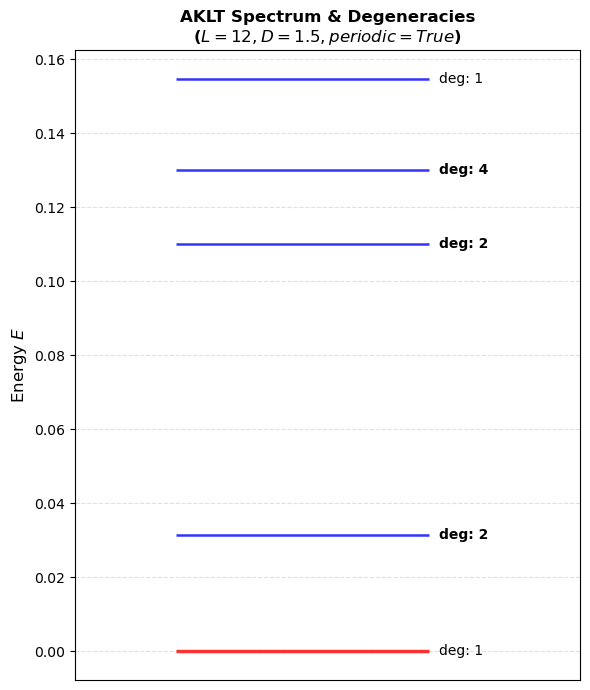

In [39]:
def plot_aniso_AKLT_spectrum(filename, L, D, periodic, atol=1e-5):
    """
    Loads eigenvalues from HDF5, calculates the degeneracy of each energy level,
    prints a summary, and plots the spectrum with degeneracy counts.
    """
    group_path = f"L_{L}/D_{D}/periodic_{periodic}"
    
    with h5py.File(filename, "r") as f:
        if group_path not in f:
            print(f"Error: Data path '{group_path}' not found in {filename}")
            return
        energies = f[group_path]["energies"][:] - f[group_path]["energies"][:][0]  # Shift energies so that the ground state is at zero
    # --- Calculate Degeneracies ---
    # Group energies that are within 'atol' of each other
    unique_energies = []
    degeneracies = []
    
    for E in energies:
        if not unique_energies:
            unique_energies.append(E)
            degeneracies.append(1)
        else:
            # Check if this energy matches an already identified unique level
            if np.isclose(E, unique_energies[-1], atol=atol):
                degeneracies[-1] += 1
            else:
                unique_energies.append(E)
                degeneracies.append(1)
                
    # --- Print Summary Table ---
    print(f"\n====================================================")
    print(f" SPECTRUM & DEGENERACY: L={L}, D={D}, periodic={periodic}")
    print(f"====================================================")
    print(f"{'Level Index':<15}{'Energy (E)':<18}{'Degeneracy':<10}")
    print(f"----------------------------------------------------")
    for idx, (E, deg) in enumerate(zip(unique_energies, degeneracies)):
        print(f"{idx:<15}{E:<18.6f}{deg:<10d}")
    print(f"====================================================\n")
    print(f"Haldane gap: {unique_energies[1] - unique_energies[0]:.6f}")
    print(f"Exact gap for AKLT: 0.350085(2)")


    # --- Plotting ---
    plt.figure(figsize=(6, 7))
    
    # Plot unique levels and label their degeneracies
    for E, deg in zip(unique_energies, degeneracies):
        # Ground state in red, excited states in blue
        color = 'red' if E == unique_energies[0] else 'blue'
        lw = 2.5 if E == unique_energies[0] else 1.8
        
        plt.hlines(E, xmin=0.2, xmax=0.7, colors=color, linewidth=lw, alpha=0.8)
        
        # Add text label for degeneracy to the right of each line
        plt.text(0.72, E, f"deg: {deg}", verticalalignment='center', fontsize=10, 
                 fontweight='bold' if deg > 1 else 'normal')

    plt.ylabel("Energy $E$", fontsize=12)
    plt.xlim(0, 1.0)
    plt.xticks([])  # Strip X ticks since it's a 1D vertical energy alignment
    plt.title(f"AKLT Spectrum & Degeneracies\n($L={L}, D={D}, periodic={periodic}$)", fontsize=12, fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

plot_aniso_AKLT_spectrum("ED_aniso_AKLT_data.h5", L=12, D=1.5, periodic=True, atol=1e-5)

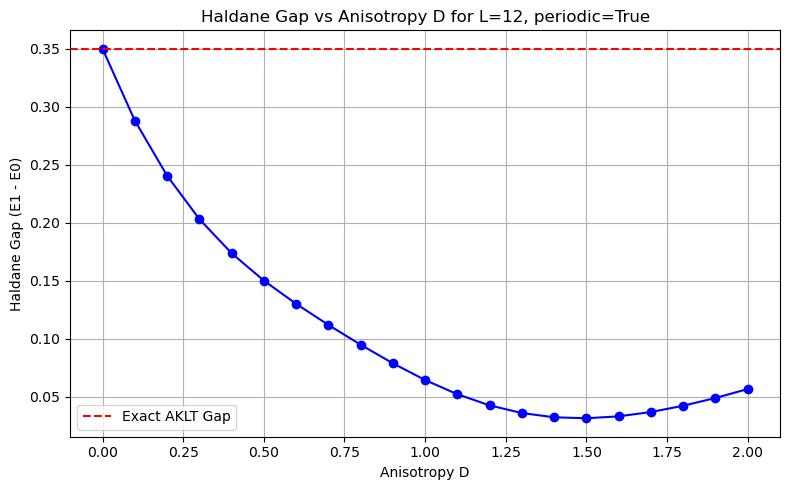

In [38]:
# Parameters
L = 12
periodic = True
filename = "ED_aniso_AKLT_data.h5"

# Plot axes
D = np.arange(0.0, 2.1, 0.1)
energies = []

# Extract energies for the first excited state (Haldane gap) from the HDF5 file
for d in D:
    d = round(d, 1)  # Round to avoid floating-point issues in group names
    if d == 0.0:
        group_path = f"L_{L}/periodic_{periodic}"

        with h5py.File("ED_AKLT_data.h5", "r") as f:
            if group_path not in f:
                print(f"Error: Data path '{group_path}' not found in ED_AKLT_data.h5")
                continue
            first_excited = f[group_path]["energies"][:][1] - f[group_path]["energies"][:][0]  # Shift energies so that the ground state is at zero
            energies.append(first_excited)
    else:
        group_path = f"L_{L}/D_{d}/periodic_{periodic}"

        with h5py.File(filename, "r") as f:
            if group_path not in f:
                print(f"Error: Data path '{group_path}' not found in {filename}")
                continue
            first_excited = f[group_path]["energies"][:][1] - f[group_path]["energies"][:][0]  # Shift energies so that the ground state is at zero
            energies.append(first_excited)

# Plot the Haldane gap as a function of D
plt.figure(figsize=(8, 5))
plt.plot(D, energies, marker='o', linestyle='-', color='b')
plt.title(f"Haldane Gap vs Anisotropy D for L={L}, periodic={periodic}")
plt.xlabel("Anisotropy D")
plt.ylabel("Haldane Gap (E1 - E0)")
plt.grid()
plt.axhline(0.350085, color='r', linestyle='--', label='Exact AKLT Gap')
plt.legend()
plt.tight_layout()
plt.show()